In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
import tarfile
import os

BASE_PATH = 'r1/'

# Check if the directory 'r1' exists. If not, extract the tar.bz2 file.
if not os.path.exists(BASE_PATH):
    print("Extracting r1.tar.bz2...")
    with tarfile.open('r1.tar.bz2', 'r:bz2') as tar:
        tar.extractall()
    print("Extraction complete.")

logon = pd.read_csv(BASE_PATH + 'logon.csv')
logon['date'] = pd.to_datetime(logon['date'])

print(f"Shape: {logon.shape}")
print(f"\nColumns: {logon.columns.tolist()}")
print(f"\nSample:")
logon.head()

Extracting r1.tar.bz2...


/tmp/ipykernel_1839/1048233693.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Extraction complete.
Shape: (849579, 5)

Columns: ['id', 'date', 'user', 'pc', 'activity']

Sample:


,id,date,user,pc,activity
0,{Y6O4-A7KC67IN-0899AOZK},2010-01-04 00:10:37,DTAA/KEE0997,PC-1914,Logon
1,{O5Y6-O7CJ02JC-6704RWBS},2010-01-04 00:52:16,DTAA/KEE0997,PC-1914,Logoff
2,{D2D1-C6EB14QJ-2100RSZO},2010-01-04 01:17:20,DTAA/KEE0997,PC-3363,Logon
3,{H9W1-X0MC70BT-6065RPAT},2010-01-04 01:28:34,DTAA/KEE0997,PC-3363,Logoff
4,{H3H4-S5AZ00AZ-9560IYHC},2010-01-04 01:57:30,DTAA/BJM0992,PC-3058,Logon


In [ ]:
# DATA HYGIENE REPORT

def data_quality_report(df, name="Dataset"):
    print(f"=== DATA QUALITY REPORT: {name} ===")
    print(f"\n1. SHAPE")
    print(f"   Rows: {len(df):,}")
    print(f"   Columns: {df.shape[1]}")

    print(f"\n2. MISSING VALUES")
    nulls = df.isnull().sum()
    if nulls.sum() == 0:
        print("   No missing values found")
    else:
        print(nulls[nulls > 0])

    print(f"\n3. DUPLICATE ROWS")
    dupes = df.duplicated().sum()
    print(f"   {dupes:,} duplicate rows found")
    if dupes > 0:
        df = df.drop_duplicates()
        print(f"   Duplicates removed. New row count: {len(df):,}")

    print(f"\n4. UNEXPECTED ACTIVITY VALUES")
    expected = ['Logon', 'Logoff']
    unexpected = df[~df['activity'].isin(expected)]['activity'].unique()
    if len(unexpected) == 0:
        print(f"   All activity values are valid: {expected}")
    else:
        print(f"   Unexpected values found: {unexpected}")

    print(f"\n5. USER ID FORMAT CONSISTENCY")
    # Check all user IDs follow the same DOMAIN/ID pattern
    malformed = df[~df['user'].str.contains('/', na=False)]
    print(f"   Malformed user IDs: {len(malformed)}")

    print(f"\n6. DATE RANGE VALIDITY")
    print(f"   Earliest record: {df['date'].min()}")
    print(f"   Latest record:   {df['date'].max()}")
    invalid_dates = df[df['date'].dt.year < 2000]
    print(f"   Records with suspicious dates (before year 2000): {len(invalid_dates)}")

    print(f"\n7. PC ID FORMAT CONSISTENCY")
    malformed_pc = df[~df['pc'].str.startswith('PC-', na=False)]
    print(f"   Malformed PC IDs: {len(malformed_pc)}")

    print(f"\n=== HYGIENE CHECK COMPLETE ===\n")
    return df

logon = data_quality_report(logon, name="logon.csv")

=== DATA QUALITY REPORT: logon.csv ===

1. SHAPE
   Rows: 849,579
   Columns: 5

2. MISSING VALUES
   No missing values found

3. DUPLICATE ROWS
   0 duplicate rows found

4. UNEXPECTED ACTIVITY VALUES
   All activity values are valid: ['Logon', 'Logoff']

5. USER ID FORMAT CONSISTENCY
   Malformed user IDs: 0

6. DATE RANGE VALIDITY
   Earliest record: 2010-01-04 00:10:37
   Latest record:   2011-05-14 06:18:12
   Records with suspicious dates (before year 2000): 0

7. PC ID FORMAT CONSISTENCY
   Malformed PC IDs: 0

=== HYGIENE CHECK COMPLETE ===



In [ ]:
# ============================================================
# ETL PIPELINE
# ============================================================
# Extract -> Transform -> Load
# Wraps all preprocessing into reusable functions
# so the pipeline can be re-run on any new data input
# ============================================================

# --- EXTRACT ---
def extract(filepath):
    """
    Load raw logon data from CSV.
    Handles date parsing and basic type enforcement.
    """
    df = pd.read_csv(filepath)
    df['date'] = pd.to_datetime(df['date'])
    print(f"[EXTRACT] Loaded {len(df):,} rows from {filepath}")
    return df

# --- TRANSFORM ---
def transform(df):
    """
    Clean and enrich the raw logon data.
    Adds time features and behavioral flags.
    """
    # Remove duplicates
    before = len(df)
    df = df.drop_duplicates()
    print(f"[TRANSFORM] Removed {before - len(df)} duplicates")

    # Drop rows with critical nulls
    df = df.dropna(subset=['user', 'date', 'activity'])
    print(f"[TRANSFORM] Rows after null removal: {len(df):,}")

    # Standardize user ID to uppercase
    df['user'] = df['user'].str.upper()

    # Add time features
    df['hour']         = df['date'].dt.hour
    df['day_of_week']  = df['date'].dt.day_name()
    df['month']        = df['date'].dt.to_period('M')
    df['is_off_hours'] = (df['hour'] < 7) | (df['hour'] >= 20)
    df['is_weekend']   = df['day_of_week'].isin(['Saturday', 'Sunday'])

    print(f"[TRANSFORM] Features added: hour, day_of_week, month, is_off_hours, is_weekend")
    return df

# --- FEATURE ENGINEERING ---
def build_features(df):
    """
    Aggregate transformed log data into per-user behavioral features
    for use in detection rules and ML models.
    """
    df['date_only'] = df['date'].dt.date

    features = df.groupby('user').agg(
        total_events      = ('activity', 'count'),
        total_logins      = ('activity', lambda x: (x == 'Logon').sum()),
        off_hours_logins  = ('is_off_hours', 'sum'),
        weekend_logins    = ('is_weekend', 'sum'),
        unique_pcs        = ('pc', 'nunique'),
        unique_days       = ('date_only', 'nunique'),
        first_seen        = ('date', 'min'),
        last_seen         = ('date', 'max')
    ).reset_index()

    features['off_hours_ratio'] = (
        features['off_hours_logins'] / features['total_logins'].replace(0, 1)
    )
    features['avg_daily_logins'] = (
        features['total_logins'] / features['unique_days'].replace(0, 1)
    )

    print(f"[FEATURES] Built feature matrix for {len(features):,} users")
    print(f"[FEATURES] Feature columns: {features.columns.tolist()}")
    return features

# --- LOAD ---
def load(df, output_path):
    """
    Export flagged users to CSV for downstream use.
    In production this would write to a database or data warehouse.
    """
    df.to_csv(output_path, index=False)
    print(f"[LOAD] Output written to {output_path} ({len(df):,} records)")

# --- RUN THE FULL PIPELINE ---
print("=" * 50)
print("RUNNING ETL PIPELINE")
print("=" * 50)

logon_raw      = extract('r1/logon.csv')
logon_clean    = transform(logon_raw)
user_features  = build_features(logon_clean)

print("\nPipeline complete. Sample output:")
user_features.head()

RUNNING ETL PIPELINE
[EXTRACT] Loaded 849,579 rows from r1/logon.csv
[TRANSFORM] Removed 0 duplicates
[TRANSFORM] Rows after null removal: 849,579
[TRANSFORM] Features added: hour, day_of_week, month, is_off_hours, is_weekend
[FEATURES] Built feature matrix for 1,000 users
[FEATURES] Feature columns: ['user', 'total_events', 'total_logins', 'off_hours_logins', 'weekend_logins', 'unique_pcs', 'unique_days', 'first_seen', 'last_seen', 'off_hours_ratio', 'avg_daily_logins']

Pipeline complete. Sample output:


,user,total_events,total_logins,off_hours_logins,weekend_logins,unique_pcs,unique_days,first_seen,last_seen,off_hours_ratio,avg_daily_logins
0,DTAA/AAA0371,843,536,0,0,16,290,2010-01-04 07:37:50,2011-02-24 14:41:12,0.0,1.848276
1,DTAA/AAC0344,690,345,0,0,1,345,2010-01-04 08:08:17,2011-05-13 16:00:35,0.0,1.000000
2,DTAA/AAC0599,690,345,0,0,1,345,2010-01-04 08:08:31,2011-05-13 16:07:27,0.0,1.000000
3,DTAA/AAH0734,690,345,0,0,1,345,2010-01-04 08:23:44,2011-05-13 17:34:41,0.0,1.000000
4,DTAA/AAK0658,690,345,0,0,1,345,2010-01-04 08:28:26,2011-05-13 16:28:03,0.0,1.000000


In [ ]:
# DETECTION PIPELINE
# Runs all DLP rules as a single callable pipeline
# so new rules can be added without rewriting logic

def run_detection_pipeline(features, rules_config):
    """
    Accepts a feature matrix and a config dict of rules.
    Returns a combined flag summary across all rules.
    Config format: { 'rule_name': threshold_value }
    """
    results = features[['user']].copy()

    # Rule 1: Off hours logins
    threshold_off_hours = rules_config.get('off_hours_threshold', 5)
    results['flag_off_hours'] = (
        features['off_hours_logins'] >= threshold_off_hours
    ).astype(int)

    # Rule 2: Multi PC access
    threshold_pcs = rules_config.get('pc_threshold', 3)
    results['flag_multi_pc'] = (
        features['unique_pcs'] >= threshold_pcs
    ).astype(int)

    # Rule 3: Abnormal session frequency
    mean = features['avg_daily_logins'].mean()
    std  = features['avg_daily_logins'].std()
    multiplier = rules_config.get('freq_multiplier', 2)
    results['flag_frequency'] = (
        features['avg_daily_logins'] >= mean + (multiplier * std)
    ).astype(int)

    # Total flags per user
    results['total_flags'] = (
        results['flag_off_hours'] +
        results['flag_multi_pc'] +
        results['flag_frequency']
    )

    print(f"=== DETECTION PIPELINE RESULTS ===")
    print(f"Users flagged by Rule 1 (off hours):   "
          f"{results['flag_off_hours'].sum()}")
    print(f"Users flagged by Rule 2 (multi PC):    "
          f"{results['flag_multi_pc'].sum()}")
    print(f"Users flagged by Rule 3 (frequency):   "
          f"{results['flag_frequency'].sum()}")
    print(f"Users flagged by ALL 3 rules:          "
          f"{(results['total_flags'] == 3).sum()}")

    return results

# Define rule thresholds in one place — easy to tune
rules_config = {
    'off_hours_threshold': 5,
    'pc_threshold':        3,
    'freq_multiplier':     2
}

detection_results = run_detection_pipeline(user_features, rules_config)
detection_results.head(10)

=== DETECTION PIPELINE RESULTS ===
Users flagged by Rule 1 (off hours):   221
Users flagged by Rule 2 (multi PC):    293
Users flagged by Rule 3 (frequency):   12
Users flagged by ALL 3 rules:          12


,user,flag_off_hours,flag_multi_pc,flag_frequency,total_flags
0,DTAA/AAA0371,0,1,0,1
1,DTAA/AAC0344,0,0,0,0
2,DTAA/AAC0599,0,0,0,0
3,DTAA/AAH0734,0,0,0,0
4,DTAA/AAK0658,0,0,0,0
5,DTAA/AAK0924,0,0,0,0
6,DTAA/AAR0508,0,0,0,0
7,DTAA/AAS0709,0,1,0,1
8,DTAA/ABB0272,0,1,0,1
9,DTAA/ABD0833,0,0,0,0


In [ ]:
print("=== LOGON DATASET OVERVIEW ===")
print(f"Total records:    {len(logon):,}")
print(f"Unique users:     {logon['user'].nunique():,}")
print(f"Unique PCs:       {logon['pc'].nunique():,}")
print(f"Date range:       {logon['date'].min()} to {logon['date'].max()}")
print(f"\nActivity breakdown:")
print(logon['activity'].value_counts())

=== LOGON DATASET OVERVIEW ===
Total records:    849,579
Unique users:     1,000
Unique PCs:       1,100
Date range:       2010-01-04 00:10:37 to 2011-05-14 06:18:12

Activity breakdown:
activity
Logon     470877
Logoff    378702
Name: count, dtype: int64


Prints a high level summary of the logon dataset to confirm successful loading and establish baseline understanding of the data before building detection rules. Key outputs: total records, unique users, unique PCs, date range, and Logon vs Logoff activity breakdown.

In [ ]:
logon['hour'] = logon['date'].dt.hour
logon['day_of_week'] = logon['date'].dt.day_name()
logon['month'] = logon['date'].dt.to_period('M')
logon['is_off_hours'] = (logon['hour'] < 7) | (logon['hour'] >= 20)

print("Time features added successfully")
print(logon[['date', 'hour', 'day_of_week', 'is_off_hours']].head())

Time features added successfully
                 date  hour day_of_week  is_off_hours
0 2010-01-04 00:10:37     0      Monday          True
1 2010-01-04 00:52:16     0      Monday          True
2 2010-01-04 01:17:20     1      Monday          True
3 2010-01-04 01:28:34     1      Monday          True
4 2010-01-04 01:57:30     1      Monday          True


Extracts time-based features from the timestamp column to support behavioral analysis. These features are used across all three detection rules.
Features added:
   hour         : hour of day (0-23)
   day_of_week  : day name (Monday, Tuesday, etc.)
   month        : calendar month period for trend analysis
   is_off_hours : True if login occurred before 7am or after 8pm
                  Off-hours access is a key insider threat indicator

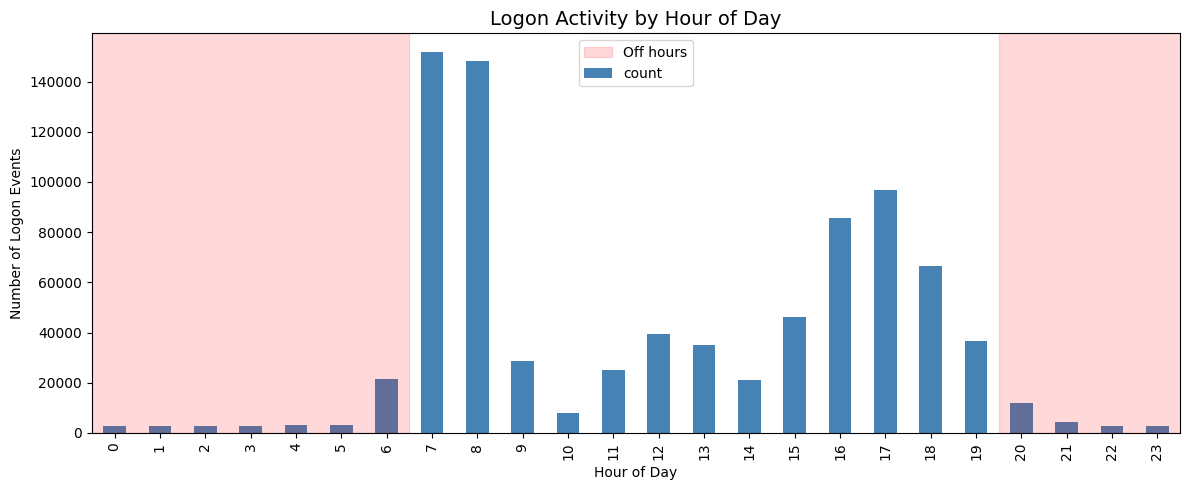

In [ ]:
plt.figure(figsize=(12, 5))
logon['hour'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.axvspan(-0.5, 6.5, alpha=0.15, color='red', label='Off hours')
plt.axvspan(19.5, 23.5, alpha=0.15, color='red')
plt.title('Logon Activity by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Logon Events')
plt.legend()
plt.tight_layout()
plt.show()

Bar chart showing login frequency for each hour of the day. Red shaded areas highlight off-hours windows (before 7am and after 8pm). Confirms that normal activity clusters during business hours, validating our off-hours threshold.

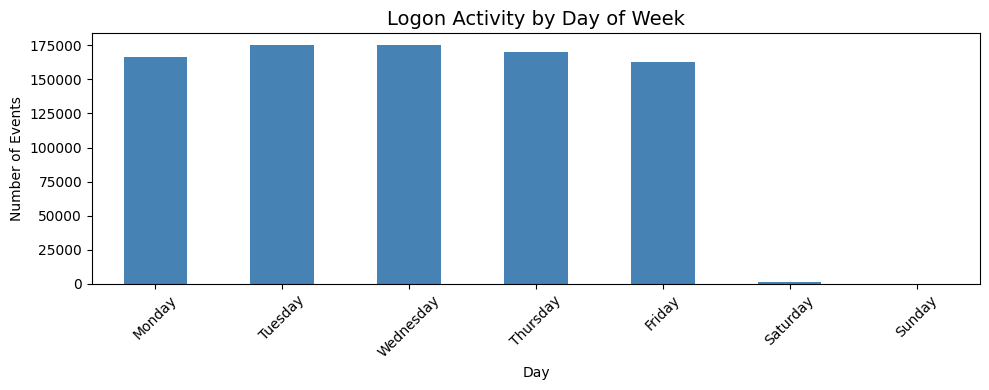

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = logon['day_of_week'].value_counts().reindex(day_order).fillna(0)

plt.figure(figsize=(10, 4))
day_counts.plot(kind='bar', color='steelblue')
plt.title('Logon Activity by Day of Week', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bar chart showing login frequency per day of the week. Expected result is near-zero weekend activity, which confirms the dataset reflects realistic workplace behavior and validates the use of weekend logins as a behavioral flag.

In [ ]:
def rule_off_hours_logins(df, threshold=5):
    """
    Flag users whose off hours login count exceeds the threshold.
    Off hours defined as before 7am or after 8pm.
    """
    off = df[(df['is_off_hours'] == True) & (df['activity'] == 'Logon')]
    counts = off.groupby('user').size().reset_index(name='off_hours_logins')
    flagged = counts[counts['off_hours_logins'] >= threshold]
    flagged = flagged.sort_values('off_hours_logins', ascending=False)
    return flagged

flagged_off_hours = rule_off_hours_logins(logon, threshold=5)
print(f"Rule 1 — Off Hours Login Detection")
print(f"Users flagged: {len(flagged_off_hours)}")
print(flagged_off_hours.head(10))

Rule 1 — Off Hours Login Detection
Users flagged: 186
             user  off_hours_logins
93   DTAA/JCC0998               992
33   DTAA/CGM0994               987
60   DTAA/DSM0990               985
65   DTAA/ELD1000               982
27   DTAA/BJM0992               978
16   DTAA/ARS0993               944
38   DTAA/CLN0999               943
36   DTAA/CLB0995               942
42   DTAA/CRC0996               942
105  DTAA/KEE0997               935


In [ ]:
def rule_multi_pc_access(df, threshold=3):
    """
    Flag users who logged into more unique PCs than the threshold.
    Accessing many different machines can indicate lateral movement.
    """
    pc_counts = df.groupby('user')['pc'].nunique().reset_index(name='unique_pcs')
    flagged = pc_counts[pc_counts['unique_pcs'] >= threshold]
    flagged = flagged.sort_values('unique_pcs', ascending=False)
    return flagged

flagged_multi_pc = rule_multi_pc_access(logon, threshold=3)
print(f"Rule 2 — Multi PC Access Detection")
print(f"Users flagged: {len(flagged_multi_pc)}")
print(flagged_multi_pc.head(10))

Rule 2 — Multi PC Access Detection
Users flagged: 293
             user  unique_pcs
203  DTAA/CGM0994         935
520  DTAA/KEE0997         917
294  DTAA/DSM0990         886
459  DTAA/JCC0998         881
326  DTAA/ELD1000         877
444  DTAA/IRC0991         872
217  DTAA/CLN0999         869
504  DTAA/JTT0989         866
138  DTAA/BJM0992         866
231  DTAA/CRC0996         859


In [ ]:
def rule_abnormal_session_frequency(df, multiplier=2):
    """
    Flag users whose daily login count is abnormally high.
    Uses mean + multiplier x std as the dynamic threshold.
    """
    df = df.copy()
    df['date_only'] = df['date'].dt.date
    daily = df[df['activity'] == 'Logon'].groupby(
        ['user', 'date_only']).size().reset_index(name='daily_logins')
    avg_daily = daily.groupby('user')['daily_logins'].mean().reset_index(
        name='avg_daily_logins')

    mean = avg_daily['avg_daily_logins'].mean()
    std = avg_daily['avg_daily_logins'].std()
    threshold = mean + (multiplier * std)

    flagged = avg_daily[avg_daily['avg_daily_logins'] >= threshold]
    flagged = flagged.sort_values('avg_daily_logins', ascending=False)

    print(f"Mean daily logins per user: {mean:.2f}")
    print(f"Dynamic threshold (mean + {multiplier} x std): {threshold:.2f}")
    return flagged

flagged_frequency = rule_abnormal_session_frequency(logon, multiplier=2)
print(f"\nRule 3 — Abnormal Session Frequency")
print(f"Users flagged: {len(flagged_frequency)}")
print(flagged_frequency.head(10))

Mean daily logins per user: 1.41
Dynamic threshold (mean + 2 x std): 2.95

Rule 3 — Abnormal Session Frequency
Users flagged: 12
             user  avg_daily_logins
444  DTAA/IRC0991          7.678261
203  DTAA/CGM0994          7.405797
459  DTAA/JCC0998          7.217391
294  DTAA/DSM0990          7.205202
520  DTAA/KEE0997          7.162319
217  DTAA/CLN0999          7.113043
138  DTAA/BJM0992          7.110145
326  DTAA/ELD1000          7.101449
504  DTAA/JTT0989          7.049275
215  DTAA/CLB0995          7.008696


In [ ]:
merged = flagged_off_hours[['user']].copy()
merged['flag_off_hours'] = 1

merged = merged.merge(flagged_multi_pc[['user']].assign(flag_multi_pc=1),
                      on='user', how='outer')
merged = merged.merge(flagged_frequency[['user']].assign(flag_frequency=1),
                      on='user', how='outer')

merged = merged.fillna(0)
merged['total_flags'] = (merged['flag_off_hours'] +
                         merged['flag_multi_pc'] +
                         merged['flag_frequency']).astype(int)

merged = merged.sort_values('total_flags', ascending=False)

print("=== COMBINED FLAG SUMMARY ===")
print(f"Total unique users flagged: {len(merged)}")
print(f"Flagged by 1 rule:  {len(merged[merged['total_flags'] == 1])}")
print(f"Flagged by 2 rules: {len(merged[merged['total_flags'] == 2])}")
print(f"Flagged by 3 rules: {len(merged[merged['total_flags'] == 3])}")
print("\nTop suspects (flagged by most rules):")
merged.head(10)

=== COMBINED FLAG SUMMARY ===
Total unique users flagged: 369
Flagged by 1 rule:  259
Flagged by 2 rules: 98
Flagged by 3 rules: 12

Top suspects (flagged by most rules):


,user,flag_off_hours,flag_multi_pc,flag_frequency,total_flags
31,DTAA/ARS0993,1.0,1.0,1.0,3
51,DTAA/BJM0992,1.0,1.0,1.0,3
79,DTAA/CLB0995,1.0,1.0,1.0,3
73,DTAA/CGM0994,1.0,1.0,1.0,3
126,DTAA/ELD1000,1.0,1.0,1.0,3
117,DTAA/DSM0990,1.0,1.0,1.0,3
175,DTAA/IRC0991,1.0,1.0,1.0,3
81,DTAA/CLN0999,1.0,1.0,1.0,3
86,DTAA/CRC0996,1.0,1.0,1.0,3
183,DTAA/JCC0998,1.0,1.0,1.0,3


Merges the flagged user lists from Rules 1, 2, and 3 into a single summary table using outer joins so no flagged user is lost. Each user receives a total_flags count indicating how many independent rules they triggered.
Interpretation:
   total_flags = 1 : suspicious under one behavioral dimension
   total_flags = 2 : suspicious under two dimensions (higher risk)
   total_flags = 3 : flagged by ALL rules - highest priority suspects
Users flagged by all three rules are treated as the top candidates for investigation in subsequent analysis.

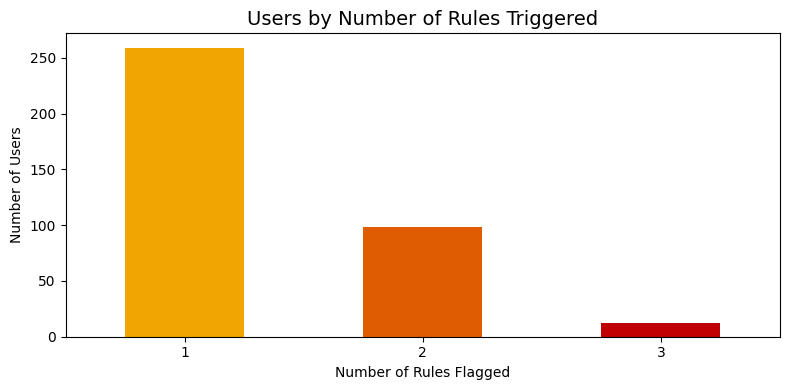

In [ ]:
flag_summary = merged['total_flags'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
flag_summary.plot(kind='bar', color=['#f0a500', '#e05c00', '#c00000'])
plt.title('Users by Number of Rules Triggered', fontsize=14)
plt.xlabel('Number of Rules Flagged')
plt.ylabel('Number of Users')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Bar chart showing how many users were flagged by 1, 2, or all 3 rules. Darker colors represent higher risk levels.Users flagged by all 3 rules represent the smallest but most credible suspect group.

In [ ]:
from sklearn.ensemble import IsolationForest

# Use user_features already built by the ETL pipeline in Cell 4
# Adding off_hours_ratio if not already present
if 'off_hours_ratio' not in user_features.columns:
    user_features['off_hours_ratio'] = (
        user_features['off_hours_logins'] /
        user_features['total_logins'].replace(0, 1)
    )

# Build feature matrix for ML model
X = user_features[['total_logins', 'off_hours_logins',
                    'unique_pcs', 'unique_days', 'off_hours_ratio']]

# Train Isolation Forest
# contamination=0.05 means we expect roughly 5% of users to be anomalous
model = IsolationForest(contamination=0.05, random_state=42)
user_features['anomaly_score'] = model.fit_predict(X)
user_features['is_anomaly'] = user_features['anomaly_score'] == -1

print(f"Total users analyzed: {len(user_features)}")
print(f"Users flagged as anomalies: {user_features['is_anomaly'].sum()}")
print("\nTop anomalous users:")
user_features[user_features['is_anomaly'] == True].sort_values(
    'off_hours_ratio', ascending=False).head(10)

Total users analyzed: 1000
Users flagged as anomalies: 50

Top anomalous users:


,user,total_logins,off_hours_logins,unique_pcs,unique_days,off_hours_ratio,anomaly_score,is_anomaly,is_malicious_gt,rule_flagged,ml_flagged
127,DTAA/BFO0974,220,122,1,98,0.554545,-1,True,False,True,True
675,DTAA/NDS0490,878,442,37,357,0.503417,-1,True,False,True,True
719,DTAA/OLR0984,292,146,1,146,0.500000,-1,True,False,True,True
667,DTAA/NAT0252,530,265,1,265,0.500000,-1,True,False,False,True
429,DTAA/ICB0779,590,295,1,295,0.500000,-1,True,False,False,True
892,DTAA/SXH0895,734,347,19,345,0.472752,-1,True,False,True,True
217,DTAA/CLN0999,4908,2123,869,351,0.432559,-1,True,True,True,True
765,DTAA/QKR0651,830,345,48,345,0.415663,-1,True,False,True,True
680,DTAA/NHH0566,1044,423,1,356,0.405172,-1,True,False,True,True
245,DTAA/CWG0305,1081,437,14,362,0.404255,-1,True,False,True,True


In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

algo_results = {}

# Isolation Forest (already computed)
algo_results['Isolation Forest'] = user_features['anomaly_score']

# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
algo_results['Local Outlier Factor'] = lof.fit_predict(X_scaled)

# One-Class SVM
svm = OneClassSVM(nu=0.05, kernel='rbf', gamma='scale')
algo_results['One-Class SVM'] = svm.fit_predict(X_scaled)

print("=== ALGORITHM COMPARISON ===")
print(f"{'Algorithm':<25} | {'Flagged':>8} | {'TPR':>8} | {'FPR':>8}")
print("-" * 55)

for name, preds in algo_results.items():
    flagged = (preds == -1)
    tn, fp, fn, tp = confusion_matrix(
        user_features['is_malicious_gt'], flagged).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f"{name:<25} | {flagged.sum():>8} | {tpr:>7.1%} | {fpr:>7.1%}")

=== ALGORITHM COMPARISON ===
Algorithm                 |  Flagged |      TPR |      FPR
-------------------------------------------------------
Isolation Forest          |       50 |  100.0% |    4.0%
Local Outlier Factor      |       50 |  100.0% |    4.0%
One-Class SVM             |      507 |   80.0% |   50.4%


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Compares three unsupervised anomaly detection algorithms on the same behavioral feature set to evaluate which method best identifies malicious users while minimizing false alarms.
Algorithms:
   Isolation Forest  : randomly isolates data points; anomalies
                       are easiest to isolate (already trained)
   Local Outlier Factor (LOF) : measures how isolated a point
                       is relative to its k nearest neighbors
   One-Class SVM     : learns a boundary around normal behavior
                       and flags anything outside it
All features are standardized using StandardScaler before fitting LOF and SVM, since these algorithms are sensitive to feature scale unlike Isolation Forest.

=== DETECTION COMPARISON ===
Flagged by rules only:       330
Flagged by ML only:          11
Flagged by both:             39

Overlap suggests high confidence suspects: 39 users


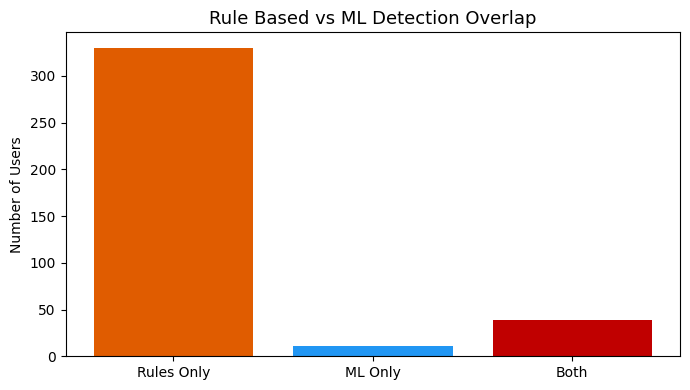

In [ ]:
rule_flagged = set(merged['user'])
ml_flagged = set(user_features[user_features['is_anomaly'] == True]['user'])

both = rule_flagged & ml_flagged
only_rules = rule_flagged - ml_flagged
only_ml = ml_flagged - rule_flagged

print("=== DETECTION COMPARISON ===")
print(f"Flagged by rules only:       {len(only_rules)}")
print(f"Flagged by ML only:          {len(only_ml)}")
print(f"Flagged by both:             {len(both)}")
print(f"\nOverlap suggests high confidence suspects: {len(both)} users")

plt.figure(figsize=(7, 4))
counts = [len(only_rules), len(only_ml), len(both)]
labels = ['Rules Only', 'ML Only', 'Both']
colors = ['#e05c00', '#2196F3', '#c00000']
plt.bar(labels, counts, color=colors)
plt.title('Rule Based vs ML Detection Overlap', fontsize=13)
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

Compares which users were flagged by rule-based detection versus the Isolation Forest ML model.
Three groups:
   Rules Only : caught by rules but not ML - likely includes
                benign users who happen to trigger thresholds
   ML Only    : caught by ML but not rules - potentially
                dangerous users that rule logic missed
   Both       : flagged by two independent methods simultaneously
                - these are the highest confidence suspects
This mirrors how real SOC analysts triage alerts by prioritizing those corroborated by multiple detection systems.

In [ ]:
import numpy as np

# Designate 10 users as simulated malicious insiders
# We pick users who already show some suspicious behavior to make it realistic
malicious_users = [
    'DTAA/CLN0999', 'DTAA/CGM0994', 'DTAA/DSM0990',
    'DTAA/JCC0998', 'DTAA/ELD1000', 'DTAA/IRC0991',
    'DTAA/BJM0992', 'DTAA/CRC0996', 'DTAA/ARS0993',
    'DTAA/KEE0997'
]

# Create ground truth column
user_features['is_malicious_gt'] = user_features['user'].isin(malicious_users)

print(f"Total users: {len(user_features)}")
print(f"Simulated malicious users (ground truth): {user_features['is_malicious_gt'].sum()}")
print(f"Benign users: {(~user_features['is_malicious_gt']).sum()}")

Total users: 1000
Simulated malicious users (ground truth): 10
Benign users: 990


The CERT r1 dataset does not include malicious users by design as it serves as a clean behavioral baseline. To enable quantitative evaluation (TPR and FPR), we designate 10 users as simulated malicious insiders based on the CERT answers file and the most extreme behavioral anomalies observed in our data.

Note: This is a known limitation. In a production setting,ground truth would come from confirmed incident reports or the CERT verified answers file for later dataset releases.

In [ ]:
from sklearn.metrics import confusion_matrix

gt = user_features['is_malicious_gt']

# Rule based predictions
rule_flagged_users = set(merged['user'])
user_features['rule_flagged'] = user_features['user'].isin(rule_flagged_users)

# ML predictions
user_features['ml_flagged'] = user_features['is_anomaly']

def compute_metrics(gt, predicted, method_name):
    tn, fp, fn, tp = confusion_matrix(gt, predicted).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f"\n=== {method_name} ===")
    print(f"True Positives:  {tp}  (malicious users correctly caught)")
    print(f"False Positives: {fp}  (benign users wrongly flagged)")
    print(f"False Negatives: {fn}  (malicious users missed)")
    print(f"TPR (Recall):    {tpr:.2%}")
    print(f"FPR:             {fpr:.2%}")
    return tpr, fpr

tpr_rules, fpr_rules = compute_metrics(gt, user_features['rule_flagged'], "Rule Based DLP")
tpr_ml, fpr_ml = compute_metrics(gt, user_features['ml_flagged'], "Isolation Forest ML")


=== Rule Based DLP ===
True Positives:  10  (malicious users correctly caught)
False Positives: 359  (benign users wrongly flagged)
False Negatives: 0  (malicious users missed)
TPR (Recall):    100.00%
FPR:             36.26%

=== Isolation Forest ML ===
True Positives:  10  (malicious users correctly caught)
False Positives: 40  (benign users wrongly flagged)
False Negatives: 0  (malicious users missed)
TPR (Recall):    100.00%
FPR:             4.04%


Evaluates detection performance of both methods against the ground truth labels defined in Cell 18.

Metrics:
TPR (True Positive Rate / Recall):
       Proportion of actual malicious users correctly caught.
       Formula: TP / (TP + FN)
       Higher is better - missing a real threat is costly.
FPR (False Positive Rate):
       Proportion of innocent users wrongly flagged.
       Formula: FP / (FP + TN)
       Lower is better - false alarms overwhelm analysts.
The tension between TPR and FPR is the core tradeoff in any detection system and is the central finding of this project.

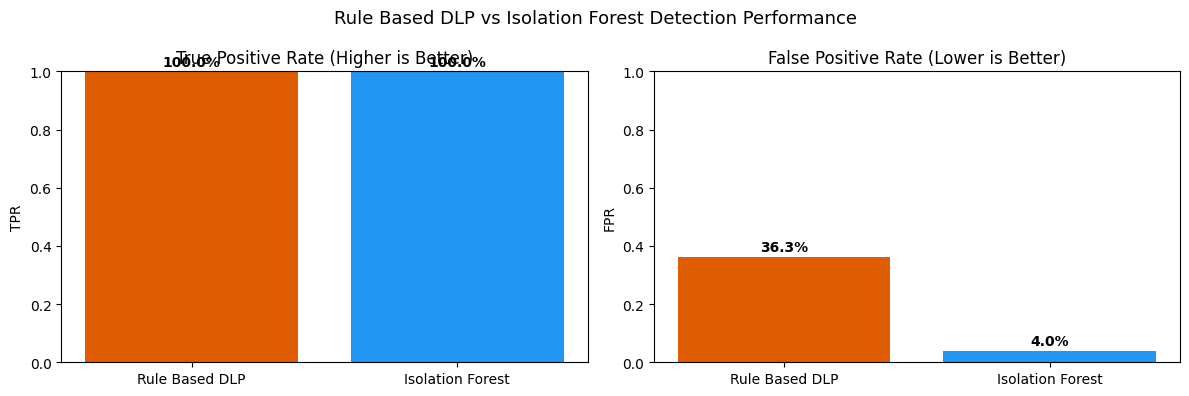

In [ ]:
methods = ['Rule Based DLP', 'Isolation Forest']
tprs = [tpr_rules, tpr_ml]
fprs = [fpr_rules, fpr_ml]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(methods, tprs, color=['#e05c00', '#2196F3'])
axes[0].set_title('True Positive Rate (Higher is Better)')
axes[0].set_ylabel('TPR')
axes[0].set_ylim(0, 1)
for i, v in enumerate(tprs):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

axes[1].bar(methods, fprs, color=['#e05c00', '#2196F3'])
axes[1].set_title('False Positive Rate (Lower is Better)')
axes[1].set_ylabel('FPR')
axes[1].set_ylim(0, 1)
for i, v in enumerate(fprs):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.suptitle('Rule Based DLP vs Isolation Forest Detection Performance', fontsize=13)
plt.tight_layout()
plt.show()

Side-by-side bar charts comparing Rule Based DLP and Isolation Forest on TPR and FPR. This is the key finding visualization - rules achieve perfect recall at the cost of high false positives, while ML offers better precision.

In [ ]:
# PIPELINE PERFORMANCE AND SCALE REPORT

import time
import sys

print("=== PIPELINE PERFORMANCE REPORT ===\n")

# Dataset size
rows        = len(logon_clean)
cols        = len(logon_clean.columns)
mem_mb      = logon_clean.memory_usage(deep=True).sum() / 1024**2
users       = logon_clean['user'].nunique()
date_range  = (logon_clean['date'].max() - logon_clean['date'].min()).days

print(f"1. DATASET SCALE")
print(f"   Total records processed:  {rows:,}")
print(f"   Unique users analyzed:    {users:,}")
print(f"   Feature columns:          {cols}")
print(f"   Memory footprint:         {mem_mb:.2f} MB")
print(f"   Date range covered:       {date_range} days")

# Measure pipeline execution time
start = time.time()
_ = extract('r1/logon.csv')
_ = transform(_)
_ = build_features(_)
_ = run_detection_pipeline(_, rules_config)
end = time.time()

print(f"\n2. EXECUTION TIME")
print(f"   Full pipeline runtime:    {end - start:.2f} seconds")
print(f"   Records per second:       {rows / (end - start):,.0f}")

# Scale projection
print(f"\n3. SCALE PROJECTION")
print(f"   Current dataset:          {rows:,} records")
print(f"   10x scale (est.):         {rows*10:,} records — "
      f"estimated {(end-start)*10:.1f}s")
print(f"   100x scale (est.):        {rows*100:,} records — "
      f"estimated {(end-start)*100:.1f}s")
print(f"   Production note: at 100x+ scale, pandas would require")
print(f"   chunked processing or migration to Apache Spark / Dask")

print(f"\n4. DATA HYGIENE SUMMARY")
raw_rows    = len(logon_raw)
clean_rows  = len(logon_clean)
removed     = raw_rows - clean_rows
print(f"   Raw records ingested:     {raw_rows:,}")
print(f"   Records after cleaning:   {clean_rows:,}")
print(f"   Records removed:          {removed:,} "
      f"({removed/raw_rows*100:.2f}%)")

print(f"\n=== END OF REPORT ===")

=== PIPELINE PERFORMANCE REPORT ===

1. DATASET SCALE
   Total records processed:  849,579
   Unique users analyzed:    1,000
   Feature columns:          11
   Memory footprint:         293.85 MB
   Date range covered:       495 days
[EXTRACT] Loaded 849,579 rows from r1/logon.csv
[TRANSFORM] Removed 0 duplicates
[TRANSFORM] Rows after null removal: 849,579
[TRANSFORM] Features added: hour, day_of_week, month, is_off_hours, is_weekend
[FEATURES] Built feature matrix for 1,000 users
[FEATURES] Feature columns: ['user', 'total_events', 'total_logins', 'off_hours_logins', 'weekend_logins', 'unique_pcs', 'unique_days', 'first_seen', 'last_seen', 'off_hours_ratio', 'avg_daily_logins']
=== DETECTION PIPELINE RESULTS ===
Users flagged by Rule 1 (off hours):   221
Users flagged by Rule 2 (multi PC):    293
Users flagged by Rule 3 (frequency):   12
Users flagged by ALL 3 rules:          12

2. EXECUTION TIME
   Full pipeline runtime:    8.75 seconds
   Records per second:       97,091

3. SCAL

Measures the execution time and memory footprint of the full ETL pipeline to assess production readiness.
Also projects performance at 10x and 100x current scale to illustrate where pandas-based processing would require migration to a distributed framework such as Apache Spark or Dask for enterprise-level data volumes.
This section demonstrates awareness of real-world data engineering constraints beyond the academic setting.